# Quantum phase estimation: measure the eigenvalue of a unitary

## The problem

A unitary gate $U$ has an eigenstate $|\psi\rangle$, meaning

$$U|\psi\rangle = e^{2\pi i\theta}|\psi\rangle$$

for some number $\theta$ between 0 and 1 (a fraction of a full turn). Quantum phase estimation (QPE) estimates $\theta$ to $t$ bits of precision. It is the core of Shor's algorithm and of many quantum chemistry methods.

## How it works

QPE is phase kickback used at $t$ different scales, followed by an inverse quantum Fourier transform (QFT).

1. Put $t$ "counting" qubits in $|+\rangle$, and the target qubit in $|\psi\rangle$.
2. Counting qubit $k$ controls $U$ applied $2^k$ times. Phase kickback leaves the phase $2\pi\theta\,2^k$ on counting qubit $k$. Together, the counting register holds a state whose phases encode the binary digits of $\theta$.
3. The inverse QFT converts those phases into a basis state: the integer $2^t\theta$ written in binary.
4. Measure the counting qubits and divide by $2^t$ to get $\theta$.

If $2^t\theta$ is a whole number, the answer is exact and every shot agrees. Otherwise the counts peak at the nearest whole numbers, with a tail on the other values. The nearest whole number always has probability at least $4/\pi^2 \approx 41\%$. More counting qubits make the estimate finer (the spacing is $1/2^t$), but they do not by themselves make the peak taller, because that depends on how close $2^t\theta$ is to a whole number.

## The unitary used here

$U = P(2\pi\theta)$, the phase gate that multiplies $|1\rangle$ by $e^{2\pi i\theta}$. The target is $|1\rangle$, which is an eigenstate. Since $U^{2^k} = P(2\pi\theta\,2^k)$, each controlled-$U^{2^k}$ is a single controlled-phase gate, with no repeated applications needed.

We use $\theta = 5/16$ and $t = 4$. Then $2^t\theta = 5$, so the answer is exact and the outcome should always be `0101`.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

`t` is the number of counting qubits and `theta` is the phase to estimate. Later, try `theta = 0.3` to see the inexact case.

In [1]:
import math
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFTGate

# _common.py (in the parent folder) runs circuits on Aer and/or IBM hardware.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)

t = 4              # counting qubits (bits of precision)
theta = 5 / 16     # phase to estimate, in turns (0 <= theta < 1)

## What answer to expect

The counting register ends up holding the integer $2^t\theta$ in binary. If that is not a whole number, the best we can do is the nearest integer (modulo $2^t$).

In [2]:
nearest = round(theta * 2**t) % 2**t
print(
    f"QPE, t={t} counting qubits, theta = {theta} "
    f"(2^t*theta = {theta * 2**t:.3f}, nearest integer {nearest} = {nearest:0{t}b})"
)

QPE, t=4 counting qubits, theta = 0.3125 (2^t*theta = 5.000, nearest integer 5 = 0101)


## Step 1: Registers, eigenstate, and superposition

We use three registers: `cnt` (the $t$ counting qubits), `targ` (one target qubit), and `meas` (classical bits for the result). The target gets an $X$ gate to become $|1\rangle$, the eigenstate of $U$. The counting qubits get Hadamards to become $|+\rangle$.

Run the step-by-step cells once, in order. They all modify the same circuit, so if you change anything, rerun from this step, which starts a fresh circuit.

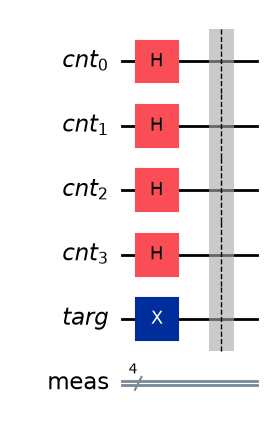

In [3]:
counting = QuantumRegister(t, name="cnt")
target = QuantumRegister(1, name="targ")
bits = ClassicalRegister(t, name="meas")
circuit = QuantumCircuit(counting, target, bits, name=f"qpe_t={t}")

circuit.x(target)
circuit.h(counting)
circuit.barrier()
circuit.draw("mpl")

## Step 2: Controlled phases (phase kickback)

Counting qubit $k$ controls $U^{2^k} = P(2\pi\theta\,2^k)$ on the target. Because the target is an eigenstate, it is unchanged, and the phase is "kicked back" onto counting qubit $k$.

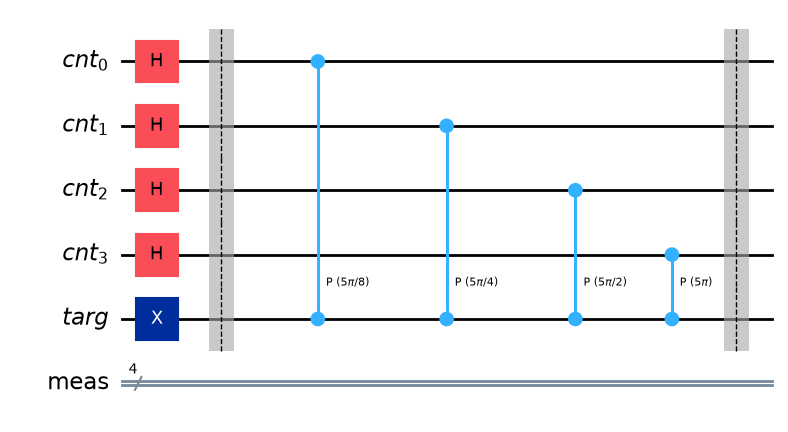

In [4]:
for k in range(t):
    circuit.cp(2 * math.pi * theta * 2**k, counting[k], target[0])
circuit.barrier()
circuit.draw("mpl")

## Step 3: Inverse QFT

The inverse QFT turns the phase pattern on the counting qubits into the binary digits of $2^t\theta$. In Qiskit it is a single gate, `QFTGate`, and `.inverse()` gives the inverse. The transpiler later breaks it into basic gates (H, controlled-phase, and SWAP).

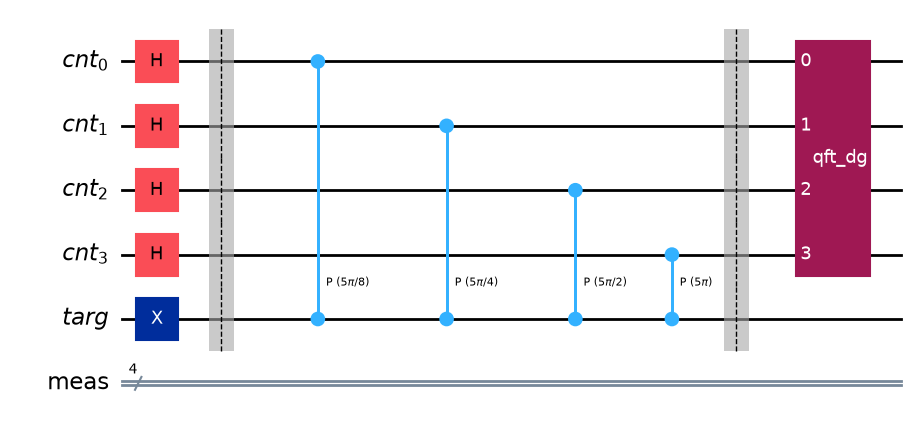

In [5]:
circuit.append(QFTGate(t).inverse(), counting)
circuit.draw("mpl")

## Step 4: Measure

Measure the counting qubits into the classical register. Qiskit prints bitstrings with qubit 0 on the *right*.

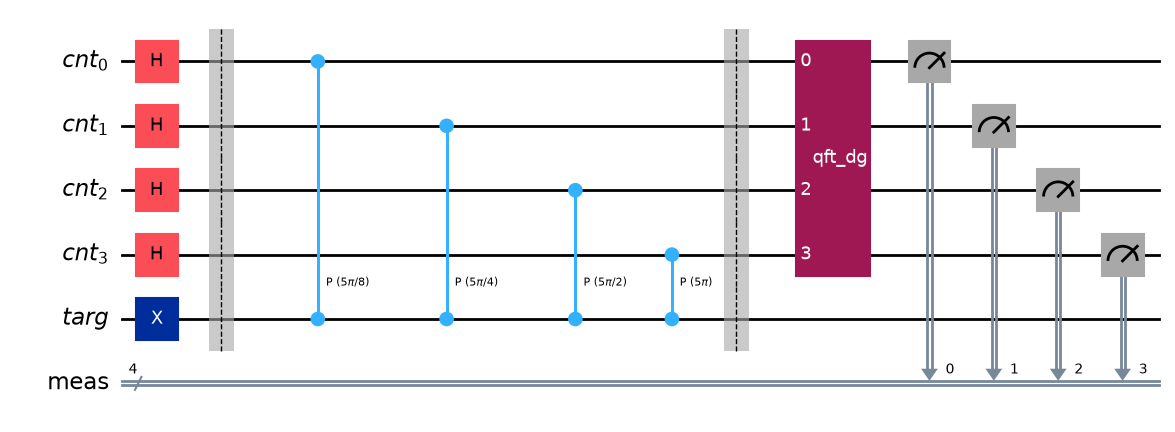

In [6]:
circuit.measure(counting, bits)
circuit.draw("mpl")

## The same circuit as one function

The steps above, collected into a reusable function. This is the function the script `phase_estimation.py` uses.

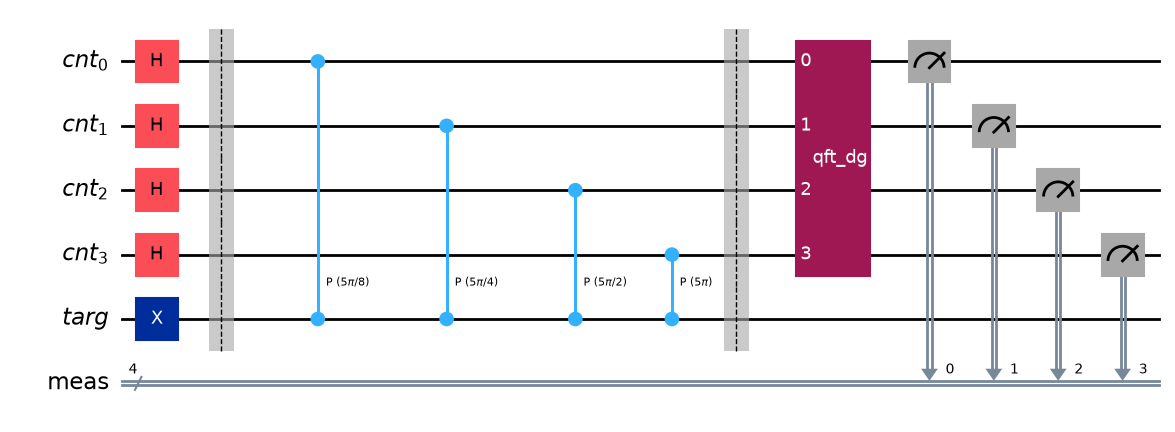

In [7]:
def build_qpe_circuit(t: int, theta: float) -> QuantumCircuit:
    """Build QPE for U = P(2*pi*theta) with eigenstate |1>.

    t is the number of counting qubits; theta is in turns (0 <= theta < 1).
    The circuit measures the t counting qubits into register "meas".
    """
    counting = QuantumRegister(t, name="cnt")
    target = QuantumRegister(1, name="targ")
    bits = ClassicalRegister(t, name="meas")
    circuit = QuantumCircuit(counting, target, bits, name=f"qpe_t={t}")

    # Step 1: target in the eigenstate |1>, counting qubits in |+>.
    circuit.x(target)
    circuit.h(counting)
    circuit.barrier()

    # Step 2: counting qubit k kicks back the phase 2*pi*theta*2^k.
    for k in range(t):
        circuit.cp(2 * math.pi * theta * 2**k, counting[k], target[0])
    circuit.barrier()

    # Step 3: inverse QFT (one high-level gate; the transpiler decomposes it).
    circuit.append(QFTGate(t).inverse(), counting)

    # Step 4: measure the counting qubits.
    circuit.measure(counting, bits)
    return circuit


qpe = build_qpe_circuit(t, theta)
qpe.draw("mpl")

## The report

This function runs once per finished run. It finds the most frequent bitstring, converts it to an estimate $\hat\theta = \text{integer}/2^t$, and checks it against the nearest integer to $2^t\theta$.

In [8]:
def report(prefix: str, name: str, counts: dict) -> None:
    total = sum(counts.values())
    best, hits = max(counts.items(), key=lambda kv: kv[1])
    estimate = int(best, 2) / 2**t
    status = "correct" if int(best, 2) == nearest else "WRONG"
    print(
        f"[{prefix}] most frequent = {best} ({hits / total:.3f}) -> "
        f"theta ~ {estimate:.4f} (true {theta}: {status})"
    )
    top = sorted(counts.items(), key=lambda kv: -kv[1])[:4]
    print(f"[{prefix}] top counts: {dict(top)}")

## Run

`run_experiments` runs the circuit on the Aer simulator and, if `skip_hardware` is `False`, on IBM hardware. For $\theta = 5/16$ and $t = 4$, expect `0101` on every shot, giving $\hat\theta = 0.3125$.

**What happens inside `run_experiments`.** For each backend, `_common.py` transpiles every circuit (`build_pubs`), wraps each one in a PUB, submits all the PUBs together as a single job, and matches each result back to its circuit (`counts_by_name`). One job means one wait in the hardware queue, however many circuits there are (here there is just one, so one PUB). Open `_common.py` to read the code.

In [9]:
run_experiments({f"qpe_t={t}": build_qpe_circuit(t, theta)}, SETTINGS, report)

Example circuit (qpe_t=4):
        ┌───┐ ░                                        ░ ┌─────────┐┌─┐      »
 cnt_0: ┤ H ├─░──■─────────────────────────────────────░─┤0        ├┤M├──────»
        ├───┤ ░  │                                     ░ │         │└╥┘┌─┐   »
 cnt_1: ┤ H ├─░──┼─────────■───────────────────────────░─┤1        ├─╫─┤M├───»
        ├───┤ ░  │         │                           ░ │  qft_dg │ ║ └╥┘┌─┐»
 cnt_2: ┤ H ├─░──┼─────────┼─────────■─────────────────░─┤2        ├─╫──╫─┤M├»
        ├───┤ ░  │         │         │                 ░ │         │ ║  ║ └╥┘»
 cnt_3: ┤ H ├─░──┼─────────┼─────────┼─────────■───────░─┤3        ├─╫──╫──╫─»
        ├───┤ ░  │P(5π/8)  │P(5π/4)  │P(5π/2)  │P(5π)  ░ └─────────┘ ║  ║  ║ »
  targ: ┤ X ├─░──■─────────■─────────■─────────■───────░─────────────╫──╫──╫─»
        └───┘ ░                                        ░             ║  ║  ║ »
meas: 4/═════════════════════════════════════════════════════════════╩══╩══╩═»
                         

0

## Try it yourself

Go back to the Setup cell, set `theta = 0.3`, and rerun everything below it. Now $2^t\theta = 4.8$ is not a whole number, so the counts peak at 5 (`0101`) with a tail on 4 (`0100`) and others. Then try `t = 5` and `t = 6`. The estimate gets finer, but the probability of the peak does not simply grow: for $\theta = 0.3$ it is about 0.88 at $t = 4$ and about 0.57 at $t = 5$, because it depends on how close $2^t\theta$ is to a whole number.